In [12]:
import duckdb
from stations.canonical_station_resolver import CanonicalStationResolver

from pathlib import Path
import pandas as pd

In [13]:
PARQUET_GLOB = 'data/silver/rides/**/*.parquet'

con = duckdb.connect()
con.execute('PRAGMA threads=4;')

required_columns = {
    'start_time_ms', 'end_time_ms',
    'start_station_name', 'end_station_name',
    'start_station_latitude', 'start_station_longitude',
    'end_station_latitude', 'end_station_longitude',
    'start_station_district', 'end_station_district',
}

schema_df = con.execute(f"DESCRIBE SELECT * FROM read_parquet('{PARQUET_GLOB}')").df()
all_columns = set(schema_df['column_name'].astype(str))
missing_required = sorted(required_columns - all_columns)

row_count = con.execute(f"SELECT COUNT(*) AS n FROM read_parquet('{PARQUET_GLOB}')").df().iloc[0, 0]

print(f'Row count: {row_count:,}')
print(f'Columns found: {len(all_columns)}')
if missing_required:
    raise ValueError(f'Missing required columns: {missing_required}')

display(schema_df)

# Canonical station key expression (coordinate-based as recommended)
start_station_key = "CAST(start_station_latitude AS VARCHAR) || ',' || CAST(start_station_longitude AS VARCHAR)"
end_station_key = "CAST(end_station_latitude AS VARCHAR) || ',' || CAST(end_station_longitude AS VARCHAR)"

Row count: 27,588,048
Columns found: 19


,column_name,column_type,null,key,default,extra
0,end_station_key,VARCHAR,YES,None,None,None
1,start_station_key,VARCHAR,YES,None,None,None
2,start_station_name,VARCHAR,YES,None,None,None
3,start_station_district,VARCHAR,YES,None,None,None
4,start_station_latitude,DOUBLE,YES,None,None,None
5,start_station_longitude,DOUBLE,YES,None,None,None
6,end_station_name,VARCHAR,YES,None,None,None
7,end_station_district,VARCHAR,YES,None,None,None
8,end_station_latitude,DOUBLE,YES,None,None,None
9,end_station_longitude,DOUBLE,YES,None,None,None


## Data Scoping – Objective & Plan

### Objective
Use `CanonicalStationResolver` from `stations/canonical_station_resolver.py` to resolve canonical station IDs for the live station feed, then scope ride data to rides where **either** start or end station is in the live canonical station set.

### Plan (task-gated)
1. **Task 1:** Build the live canonical station scope from current live stations.
2. **Task 2:** Filter rides data keeping rows where `start_canonical_station_id` OR `end_canonical_station_id` is in the live scope.

Following your instruction: run and validate each task before moving to the next.

In [16]:
# Task 1: resolve live stations to canonical station IDs
import importlib
from src.stations import canonical_station_resolver as csr
csr = importlib.reload(csr)
CanonicalStationResolver = csr.CanonicalStationResolver

mapping_parquet_dir = Path("data/silver/station_cleaning/station_direct_match_mapping")
mapping_csv_dir = Path("data/silver/station_cleaning/station_direct_match_mapping_csv")

if mapping_parquet_dir.exists():
    canonical_mapping_df = pd.read_parquet(mapping_parquet_dir)
    mapping_source = str(mapping_parquet_dir)
elif mapping_csv_dir.exists():
    csv_parts = sorted(mapping_csv_dir.glob("part-*.csv"))
    if not csv_parts:
        raise FileNotFoundError(f"No part CSV files found in: {mapping_csv_dir}")
    canonical_mapping_df = pd.read_csv(csv_parts[0])
    mapping_source = str(csv_parts[0])
else:
    raise FileNotFoundError(
        "Missing mapping artifact. Expected one of: "
        f"{mapping_parquet_dir} or {mapping_csv_dir}"
    )

resolver = CanonicalStationResolver(canonical_mapping_df)
live_stations_df = CanonicalStationResolver.load_live_stations()

live_scope_df = live_stations_df[['station_id', 'name', 'lat', 'lon']].copy()
live_scope_df['canonical_station_id'] = live_scope_df.apply(
    lambda row: resolver.resolve_id(row['name'], row['lat'], row['lon']),
    axis=1,
)

live_scope_df = live_scope_df[live_scope_df['canonical_station_id'].notna()].copy()
live_canonical_ids = sorted(live_scope_df['canonical_station_id'].drop_duplicates().tolist())

print(f"Mapping source: {mapping_source}")
print(f"Live stations retrieved: {len(live_stations_df):,}")
print(f"Live stations resolved to canonical IDs: {len(live_scope_df):,}")
print(f"Unique live canonical station IDs: {len(live_canonical_ids):,}")

display(live_scope_df.head(20))

Mapping source: data/silver/station_cleaning/station_direct_match_mapping
Live stations retrieved: 240
Live stations resolved to canonical IDs: 240
Unique live canonical station IDs: 240


,station_id,name,lat,lon,canonical_station_id
0,3,Clark / Ontario,45.510494,-73.566921,STN_0702
1,15,Métro Berri-UQAM (St-Denis / de Maisonneuve),45.514252,-73.561502,STN_1160
2,17,Marché St-Jacques (Atateken),45.520666,-73.563915,STN_0110
3,19,Métro Sherbrooke (de Rigaud / Berri),45.518093,-73.568026,STN_0017
4,24,Notre-Dame / St-Gabriel,45.507173,-73.555087,STN_0513
5,25,de la Commune / Place Jacques-Cartier,45.507610,-73.551836,STN_0004
6,26,de Maisonneuve / Mansfield (sud),45.501827,-73.573642,STN_0103
7,31,Métro Place-d'Armes (St-Urbain / Viger),45.506323,-73.559699,STN_1181
8,34,Viger / Chenneville,45.505382,-73.560937,STN_0299
9,35,de la Commune / St-Sulpice,45.504242,-73.553469,STN_0014


In [17]:
# Task 2: filter rides to live-station scope (start OR end in live canonical set)
required_canonical_cols = {'start_canonical_station_id', 'end_canonical_station_id'}
missing_canonical_cols = sorted(required_canonical_cols - all_columns)
if missing_canonical_cols:
    raise ValueError(
        f"Missing canonical ID columns required for data scoping: {missing_canonical_cols}. "
        "Run silver augmentation first to create canonical station IDs in rides data."
    )

live_canonical_ids_df = pd.DataFrame({'canonical_station_id': live_canonical_ids})
con.register('live_canonical_ids_df', live_canonical_ids_df)

scoped_count_query = f"""
SELECT COUNT(*) AS scoped_rows
FROM read_parquet('{PARQUET_GLOB}') r
WHERE r.start_canonical_station_id IN (SELECT canonical_station_id FROM live_canonical_ids_df)
   OR r.end_canonical_station_id IN (SELECT canonical_station_id FROM live_canonical_ids_df)
"""
scoped_row_count = int(con.execute(scoped_count_query).df().iloc[0, 0])
scoped_pct = (100.0 * scoped_row_count / row_count) if row_count else 0.0

data_scoping_query = f"""
SELECT *
FROM read_parquet('{PARQUET_GLOB}') r
WHERE r.start_canonical_station_id IN (SELECT canonical_station_id FROM live_canonical_ids_df)
   OR r.end_canonical_station_id IN (SELECT canonical_station_id FROM live_canonical_ids_df)
"""
con.execute(f"CREATE OR REPLACE TEMP VIEW rides_data_scoping AS {data_scoping_query}")

scoped_sample_df = con.execute("""
SELECT
    start_canonical_station_id,
    end_canonical_station_id,
    start_station_name,
    end_station_name,
    start_time_ms,
    end_time_ms
FROM rides_data_scoping
LIMIT 20
""").df()

print('Data scoping complete.')
print(f'Total rides rows: {row_count:,}')
print(f'Scoped rides rows: {scoped_row_count:,}')
print(f'Scoped coverage: {scoped_pct:.2f}%')
print("Temporary view created: rides_data_scoping")

display(scoped_sample_df)

Data scoping complete.
Total rides rows: 27,588,048
Scoped rides rows: 13,166,227
Scoped coverage: 47.72%
Temporary view created: rides_data_scoping


,start_canonical_station_id,end_canonical_station_id,start_station_name,end_station_name,start_time_ms,end_time_ms
0,STN_0165,STN_0057,Laval / Duluth,s Émile-Duployé / Rachel,2024-09-03 12:32:46,2024-09-03 12:38:29
1,STN_0631,STN_0007,Fullum / Ste-Catherine,Métro Papineau (Dorion / De Maisonneuve),2024-09-03 15:41:05,2024-09-03 15:43:50
2,STN_0046,STN_0123,Chomedey / de Maisonneuve,Marché Atwater,2024-09-03 12:54:41,2024-09-03 13:01:50
3,STN_0023,STN_0138,St-Hubert / de Maisonneuve (sud),St-Dominique / Laurier,2024-09-03 15:18:50,2024-09-03 15:37:00
4,STN_0025,STN_0491,Parc Jeanne-Mance (monument sir George-Étienne...,Clark / Evans,2024-09-04 00:45:12,2024-09-04 00:53:02
5,STN_0747,STN_0051,Parc Olympique (Pie-IX / Sherbrooke),Parthenais / du Mont-Royal,2024-09-03 21:44:40,2024-09-03 22:04:36
6,STN_0085,STN_0113,Rachel / de Brébeuf,Gare d'autocars de Montréal (Berri / Ontario),2024-09-03 20:14:19,2024-09-03 20:27:46
7,STN_0015,STN_0291,Smith / Peel,Letourneux / Ste-Catherine,2024-09-03 23:38:32,2024-09-04 00:12:09
8,STN_0023,STN_0008,St-Hubert / de Maisonneuve (sud),Métro St-Laurent (de Maisonneuve / St-Laurent),2024-09-03 12:38:54,2024-09-03 12:42:22
9,STN_0814,STN_0160,Lincoln / St-Marc,Melville / de Maisonneuve,2024-09-03 20:51:59,2024-09-03 21:04:11


## Stockout Risk Analysis – Objective & Plan

### Objective
Estimate when a station may run out of bikes by finding time windows `X` where cumulative net flow (`inflow - outflow`) becomes negative enough that `-net_flow > station_capacity`.

### Plan (task-gated)
1. **Task 1:** Build station-level hourly net flow (`+1` arrivals, `-1` departures) and join station capacity from live stations.
2. **Task 2:** Evaluate candidate windows `X` (hours) and measure stockout-risk incidence.
3. **Task 3:** Visualize metrics vs `X` and propose a reasonable `X` for downstream use.

In [20]:
# Task 1: build station-event net flow and cumulative net flow across time
import numpy as np

live_capacity_df = live_stations_df[['station_id', 'name', 'lat', 'lon', 'capacity']].copy()
live_capacity_df['canonical_station_id'] = live_capacity_df.apply(
    lambda row: resolver.resolve_id(row['name'], row['lat'], row['lon']),
    axis=1,
 )
live_capacity_df['capacity'] = pd.to_numeric(live_capacity_df['capacity'], errors='coerce')
live_capacity_df = live_capacity_df[
    live_capacity_df['canonical_station_id'].notna() & live_capacity_df['capacity'].notna()
].copy()

station_capacity_df = (
    live_capacity_df.groupby('canonical_station_id', as_index=False)
    .agg(
        station_capacity=('capacity', 'max'),
        live_station_records=('station_id', 'count')
    )
)
con.register('station_capacity_df', station_capacity_df)

con.execute("""
CREATE OR REPLACE TEMP VIEW station_hourly_net_flow AS
WITH departures AS (
    SELECT
        start_canonical_station_id AS canonical_station_id,
        CAST(start_time_ms AS TIMESTAMP) AS event_ts,
        -1 AS delta
    FROM rides_data_scoping
    WHERE start_canonical_station_id IS NOT NULL
), arrivals AS (
    SELECT
        end_canonical_station_id AS canonical_station_id,
        CAST(end_time_ms AS TIMESTAMP) AS event_ts,
        1 AS delta
    FROM rides_data_scoping
    WHERE end_canonical_station_id IS NOT NULL
), events AS (
    SELECT * FROM departures
    UNION ALL
    SELECT * FROM arrivals
)
SELECT
    canonical_station_id,
    event_ts,
    delta,
    SUM(delta) OVER (
        PARTITION BY canonical_station_id
        ORDER BY event_ts
        ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
    ) AS cumulative_net_flow
FROM events
""")

station_hourly_summary_df = con.execute("""
SELECT
    COUNT(*) AS station_event_rows,
    COUNT(DISTINCT canonical_station_id) AS stations_in_flow
FROM station_hourly_net_flow
""").df()

station_hourly_sample_df = con.execute("""
SELECT
    f.canonical_station_id,
    s.station_capacity,
    f.event_ts,
    f.delta,
    f.cumulative_net_flow
FROM station_hourly_net_flow f
LEFT JOIN station_capacity_df s USING (canonical_station_id)
ORDER BY f.event_ts
LIMIT 20
""").df()

print(f"Live stations with capacity mapped: {len(live_capacity_df):,}")
print(f"Canonical stations with capacity: {len(station_capacity_df):,}")
display(station_hourly_summary_df)
display(station_hourly_sample_df)

Live stations with capacity mapped: 240
Canonical stations with capacity: 240


,station_event_rows,stations_in_flow
0,26295452,1673


,canonical_station_id,station_capacity,event_ts,delta,cumulative_net_flow
0,STN_0024,35,2024-01-01 05:00:27,-1,-1.0
1,STN_0812,<NA>,2024-01-01 05:01:22,-1,-1.0
2,STN_0113,<NA>,2024-01-01 05:05:32,1,1.0
3,STN_0011,27,2024-01-01 05:07:39,-1,-1.0
4,STN_0812,<NA>,2024-01-01 05:08:38,-1,-2.0
5,STN_0386,<NA>,2024-01-01 05:10:52,-1,-1.0
6,STN_0386,<NA>,2024-01-01 05:10:56,-1,-2.0
7,STN_0150,15,2024-01-01 05:11:04,-1,-1.0
8,STN_0299,37,2024-01-01 05:14:02,-1,-1.0
9,STN_0048,61,2024-01-01 05:14:53,-1,-1.0


In [23]:
# Task 2: evaluate candidate X windows for stockout-risk signal
candidate_x_hours = list(range(4, 19))
window_metrics = []

for x_hours in candidate_x_hours:
    preceding_hours = x_hours - 1
    metrics_query = f"""
    WITH base AS (
        SELECT
            f.canonical_station_id,
            f.event_ts,
            CAST(f.delta AS DOUBLE) AS delta,
            CAST(s.station_capacity AS DOUBLE) AS station_capacity
        FROM station_hourly_net_flow f
        INNER JOIN station_capacity_df s USING (canonical_station_id)
    ), rolling AS (
        SELECT
            canonical_station_id,
            event_ts,
            station_capacity,
            SUM(delta) OVER (
                PARTITION BY canonical_station_id
                ORDER BY event_ts
                RANGE BETWEEN INTERVAL {preceding_hours} HOUR PRECEDING AND CURRENT ROW
            ) AS rolling_net_flow
        FROM base
    ), scored AS (
        SELECT
            canonical_station_id,
            event_ts,
            station_capacity,
            rolling_net_flow,
            -rolling_net_flow AS negative_deficit,
            (-rolling_net_flow > station_capacity) AS stockout_risk
        FROM rolling
    )
    SELECT
        {x_hours} AS x_hours,
        COUNT(*) AS station_event_rows,
        SUM(CASE WHEN stockout_risk THEN 1 ELSE 0 END) AS flagged_station_event_rows,
        100.0 * SUM(CASE WHEN stockout_risk THEN 1 ELSE 0 END) / NULLIF(COUNT(*), 0) AS flagged_station_event_rate_pct,
        COUNT(DISTINCT canonical_station_id) AS stations_evaluated,
        COUNT(DISTINCT CASE WHEN stockout_risk THEN canonical_station_id END) AS stations_flagged,
        100.0 * COUNT(DISTINCT CASE WHEN stockout_risk THEN canonical_station_id END) / NULLIF(COUNT(DISTINCT canonical_station_id), 0) AS stations_flagged_rate_pct,
        AVG(CASE WHEN stockout_risk THEN negative_deficit END) AS avg_deficit_when_flagged,
        quantile_cont(negative_deficit, 0.95) AS p95_negative_deficit,
        MAX(negative_deficit) AS max_negative_deficit
    FROM scored
    """
    window_metrics.append(con.execute(metrics_query).df())

x_window_metrics_df = pd.concat(window_metrics, ignore_index=True).sort_values('x_hours').reset_index(drop=True)
x_window_metrics_df['delta_stations_flagged'] = x_window_metrics_df['stations_flagged'].diff().fillna(0).astype(int)
x_window_metrics_df['delta_flagged_rate_pct'] = x_window_metrics_df['flagged_station_event_rate_pct'].diff().fillna(0.0)

display(x_window_metrics_df)

,x_hours,station_event_rows,flagged_station_event_rows,flagged_station_event_rate_pct,stations_evaluated,stations_flagged,stations_flagged_rate_pct,avg_deficit_when_flagged,p95_negative_deficit,max_negative_deficit,delta_stations_flagged,delta_flagged_rate_pct
0,4,15945841,178948.0,1.122224,240,111,46.250000,44.922234,18.0,521.0,0,0.000000
1,5,15945841,290325.0,1.820694,240,127,52.916667,44.562545,21.0,517.0,16,0.698471
2,6,15945841,410126.0,2.571994,240,143,59.583333,44.355961,23.0,504.0,16,0.751299
3,7,15945841,520431.0,3.263741,240,152,63.333333,44.380047,25.0,451.0,9,0.691748
4,8,15945841,622964.0,3.906749,240,153,63.750000,44.365394,27.0,296.0,1,0.643008
5,9,15945841,711817.0,4.463966,240,155,64.583333,44.310567,28.0,386.0,2,0.557217
6,10,15945841,788651.0,4.945810,240,161,67.083333,44.199088,29.0,522.0,6,0.481844
7,11,15945841,857786.0,5.379371,240,174,72.500000,44.098997,30.0,524.0,13,0.433561
8,12,15945841,926620.0,5.811045,240,170,70.833333,43.934236,31.0,477.0,-4,0.431674
9,13,15945841,998389.0,6.261125,240,165,68.750000,43.860992,32.0,524.0,-5,0.450080


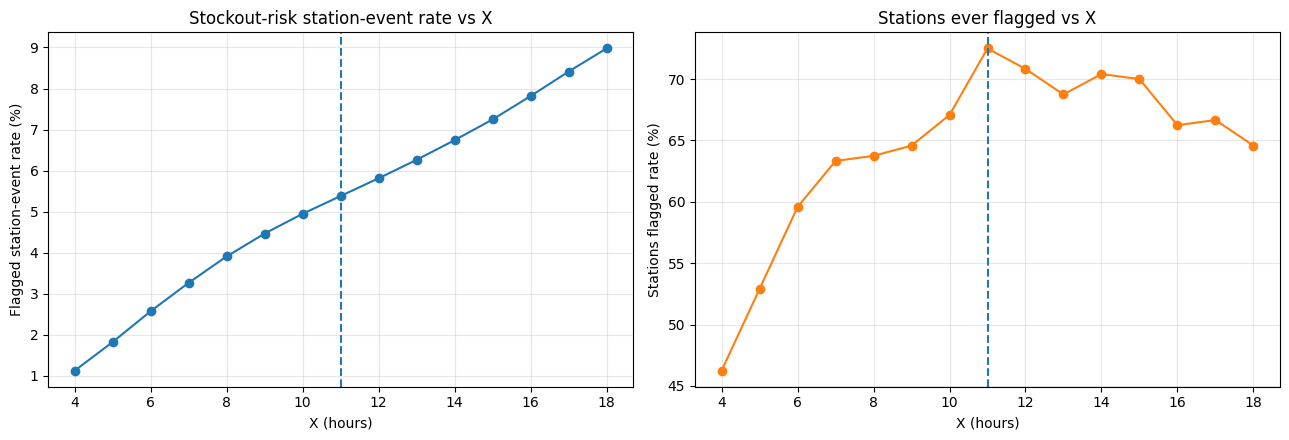

Recommended X (hours): 11
Reason: highest station coverage with penalty on over-flagging station-events.
At X=11h -> stations_flagged_rate=72.50%, flagged_station_event_rate=5.38%


,x_hours,stations_flagged_rate_pct,flagged_station_event_rate_pct,signal_quality_score
0,4,46.250000,1.122224,44.566665
1,5,52.916667,1.820694,50.185625
2,6,59.583333,2.571994,55.725343
3,7,63.333333,3.263741,58.437721
4,8,63.750000,3.906749,57.889876
5,9,64.583333,4.463966,57.887384
6,10,67.083333,4.945810,59.664618
7,11,72.500000,5.379371,64.430943
8,12,70.833333,5.811045,62.116766
9,13,68.750000,6.261125,59.358313


In [24]:
# Task 3: visualize X tradeoffs and propose a reasonable X
import matplotlib.pyplot as plt

viz_df = x_window_metrics_df.copy().sort_values('x_hours').reset_index(drop=True)
viz_df['signal_quality_score'] = (
    viz_df['stations_flagged_rate_pct'] - 1.5 * viz_df['flagged_station_event_rate_pct']
 )

recommended_row = viz_df.loc[viz_df['signal_quality_score'].idxmax()]
recommended_x_hours = int(recommended_row['x_hours'])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(viz_df['x_hours'], viz_df['flagged_station_event_rate_pct'], marker='o')
axes[0].axvline(recommended_x_hours, linestyle='--')
axes[0].set_title('Stockout-risk station-event rate vs X')
axes[0].set_xlabel('X (hours)')
axes[0].set_ylabel('Flagged station-event rate (%)')
axes[0].grid(alpha=0.3)

axes[1].plot(viz_df['x_hours'], viz_df['stations_flagged_rate_pct'], marker='o', color='tab:orange')
axes[1].axvline(recommended_x_hours, linestyle='--')
axes[1].set_title('Stations ever flagged vs X')
axes[1].set_xlabel('X (hours)')
axes[1].set_ylabel('Stations flagged rate (%)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print('Recommended X (hours):', recommended_x_hours)
print('Reason: highest station coverage with penalty on over-flagging station-events.')
print(
    f"At X={recommended_x_hours}h -> stations_flagged_rate={recommended_row['stations_flagged_rate_pct']:.2f}%, "
    f"flagged_station_event_rate={recommended_row['flagged_station_event_rate_pct']:.2f}%"
 )

display(viz_df[['x_hours', 'stations_flagged_rate_pct', 'flagged_station_event_rate_pct', 'signal_quality_score']])

In [25]:
# Task 1: build flagged-event table for X=11h
selected_x_hours = 11
preceding_hours = selected_x_hours - 1

con.execute(f"""
CREATE OR REPLACE TEMP VIEW station_stockout_events_x11 AS
WITH base AS (
    SELECT
        f.canonical_station_id,
        f.event_ts,
        CAST(f.delta AS DOUBLE) AS delta,
        CAST(s.station_capacity AS DOUBLE) AS station_capacity
    FROM station_hourly_net_flow f
    INNER JOIN station_capacity_df s USING (canonical_station_id)
), rolling AS (
    SELECT
        canonical_station_id,
        event_ts,
        station_capacity,
        SUM(delta) OVER (
            PARTITION BY canonical_station_id
            ORDER BY event_ts
            RANGE BETWEEN INTERVAL {preceding_hours} HOUR PRECEDING AND CURRENT ROW
        ) AS rolling_net_flow
    FROM base
), scored AS (
    SELECT
        canonical_station_id,
        event_ts,
        station_capacity,
        rolling_net_flow,
        -rolling_net_flow AS negative_deficit,
        CASE WHEN -rolling_net_flow > station_capacity THEN 1 ELSE 0 END AS stockout_risk_flag
    FROM rolling
), transitions AS (
    SELECT
        *,
        LAG(stockout_risk_flag, 1, 0) OVER (PARTITION BY canonical_station_id ORDER BY event_ts) AS prev_flag
    FROM scored
)
SELECT
    canonical_station_id,
    event_ts,
    station_capacity,
    rolling_net_flow,
    negative_deficit,
    stockout_risk_flag,
    CASE WHEN stockout_risk_flag = 1 AND prev_flag = 0 THEN 1 ELSE 0 END AS flag_start
FROM transitions
""")

flagged_summary_df = con.execute("""
SELECT
    COUNT(*) AS total_events_evaluated,
    SUM(stockout_risk_flag) AS flagged_events,
    100.0 * SUM(stockout_risk_flag) / NULLIF(COUNT(*), 0) AS flagged_event_rate_pct,
    COUNT(DISTINCT canonical_station_id) AS stations_evaluated,
    COUNT(DISTINCT CASE WHEN stockout_risk_flag = 1 THEN canonical_station_id END) AS stations_flagged
FROM station_stockout_events_x11
""").df()

flagged_sample_df = con.execute("""
SELECT *
FROM station_stockout_events_x11
WHERE stockout_risk_flag = 1
ORDER BY event_ts
LIMIT 20
""").df()

display(flagged_summary_df)
display(flagged_sample_df)

,total_events_evaluated,flagged_events,flagged_event_rate_pct,stations_evaluated,stations_flagged
0,15945841,857786.0,5.379371,240,174


,canonical_station_id,event_ts,station_capacity,rolling_net_flow,negative_deficit,stockout_risk_flag,flag_start
0,STN_0062,2024-01-04 19:35:25,19.0,-20.0,20.0,1,1
1,STN_0062,2024-01-04 20:10:26,19.0,-20.0,20.0,1,1
2,STN_0062,2024-01-04 20:21:26,19.0,-21.0,21.0,1,0
3,STN_0062,2024-01-04 20:31:51,19.0,-20.0,20.0,1,0
4,STN_0002,2024-01-13 00:18:38,23.0,-24.0,24.0,1,1
5,STN_0002,2024-01-13 00:21:33,23.0,-24.0,24.0,1,1
6,STN_0002,2024-01-13 00:22:00,23.0,-25.0,25.0,1,0
7,STN_0002,2024-01-13 00:22:05,23.0,-26.0,26.0,1,0
8,STN_0002,2024-01-13 00:22:15,23.0,-27.0,27.0,1,0
9,STN_0002,2024-01-13 00:24:25,23.0,-26.0,26.0,1,0


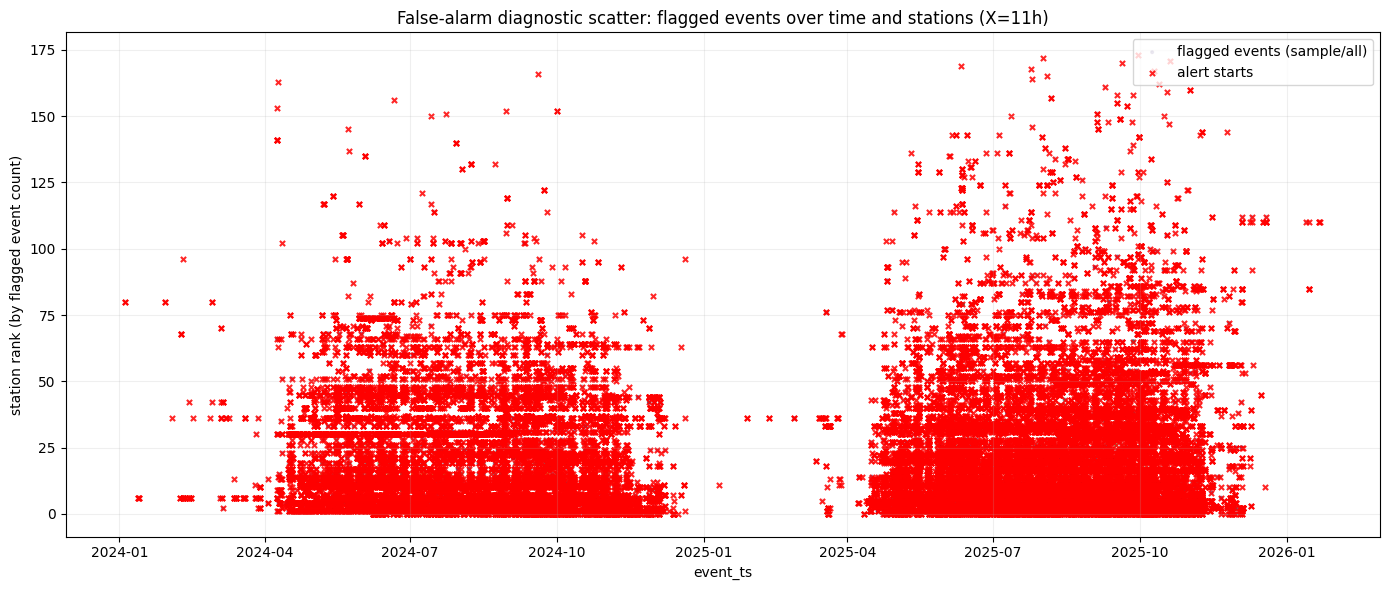

Stations with alerts: 174
Total flagged events: 857,786
Alert starts: 37,972


In [39]:
# Task 2: scatter plot across station-space and event-time for flagged events
import matplotlib.pyplot as plt

station_order_df = con.execute("""
SELECT
    canonical_station_id,
    COUNT(*) AS flagged_events
FROM station_stockout_events_x11
WHERE stockout_risk_flag = 1
GROUP BY canonical_station_id
ORDER BY flagged_events DESC, canonical_station_id
""").df()
station_order_df['station_rank'] = range(len(station_order_df))

flagged_scatter_df = con.execute("""
SELECT
    canonical_station_id,
    event_ts,
    station_capacity,
    negative_deficit,
    (negative_deficit - station_capacity) AS excess_over_capacity
FROM station_stockout_events_x11
WHERE stockout_risk_flag = 1
""").df()
flagged_scatter_df = flagged_scatter_df.merge(
    station_order_df[['canonical_station_id', 'station_rank']],
    on='canonical_station_id',
    how='left',
)

# Keep all alert starts, sample continuing alerts for readability
alert_starts_df = con.execute("""
SELECT
    canonical_station_id,
    event_ts,
    station_capacity,
    negative_deficit,
    (negative_deficit - station_capacity) AS excess_over_capacity
FROM station_stockout_events_x11
WHERE stockout_risk_flag = 1 AND flag_start = 1
""").df()
alert_starts_df = alert_starts_df.merge(
    station_order_df[['canonical_station_id', 'station_rank']],
    on='canonical_station_id',
    how='left',
)

continuation_df = flagged_scatter_df.copy()
if len(continuation_df) > 120000:
    continuation_df = continuation_df.sample(120000, random_state=42)

plot_df = pd.concat([continuation_df, alert_starts_df], ignore_index=True)
plot_df['is_start'] = False
plot_df.loc[plot_df.index >= len(continuation_df), 'is_start'] = True

fig, ax = plt.subplots(figsize=(14, 6))
ax.scatter(
    continuation_df['event_ts'], continuation_df['station_rank'],
    s=4, alpha=0.08, label='flagged events (sample/all)',
    c=continuation_df['excess_over_capacity'].clip(lower=0, upper=40), cmap='viridis',
)
ax.scatter(
    alert_starts_df['event_ts'], alert_starts_df['station_rank'],
    s=14, alpha=0.85, label='alert starts', c='red', marker='x',
)
ax.set_title('False-alarm diagnostic scatter: flagged events over time and stations (X=11h)')
ax.set_xlabel('event_ts')
ax.set_ylabel('station rank (by flagged event count)')
ax.legend(loc='upper right')
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

print(f"Stations with alerts: {station_order_df['canonical_station_id'].nunique():,}")
print(f"Total flagged events: {len(flagged_scatter_df):,}")
print(f"Alert starts: {len(alert_starts_df):,}")

In [38]:
# Task 3: persistence-based false-alarm proxy and improved alerting rule
episode_df = con.execute("""
WITH flagged AS (
    SELECT
        canonical_station_id,
        event_ts,
        station_capacity,
        negative_deficit,
        (negative_deficit - station_capacity) AS excess_over_capacity,
        flag_start
    FROM station_stockout_events_x11
    WHERE stockout_risk_flag = 1
), episode_marked AS (
    SELECT
        *,
        SUM(flag_start) OVER (
            PARTITION BY canonical_station_id
            ORDER BY event_ts
            ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
        ) AS episode_id
    FROM flagged
), episode_agg AS (
    SELECT
        canonical_station_id,
        episode_id,
        MIN(event_ts) AS episode_start_ts,
        MAX(event_ts) AS episode_end_ts,
        COUNT(*) AS flagged_event_count,
        MAX(excess_over_capacity) AS peak_excess_over_capacity,
        AVG(excess_over_capacity) AS avg_excess_over_capacity
    FROM episode_marked
    GROUP BY canonical_station_id, episode_id
), episode_scored AS (
    SELECT
        *,
        date_diff('minute', episode_start_ts, episode_end_ts) AS episode_duration_min,
        CASE
            WHEN date_diff('minute', episode_start_ts, episode_end_ts) <= 15
             AND peak_excess_over_capacity <= 2 THEN 1
            ELSE 0
        END AS likely_false_alarm
    FROM episode_agg
)
SELECT * FROM episode_scored
""").df()

episode_agg_df = episode_df.agg(
    total_episodes=('episode_id', 'count'),
    median_duration_min=('episode_duration_min', 'median'),
    p90_duration_min=('episode_duration_min', lambda s: s.quantile(0.90)),
    likely_false_alarm_episodes=('likely_false_alarm', 'sum')
)

episode_summary_df = pd.DataFrame([
    {
        'total_episodes': float(episode_agg_df.loc['total_episodes'].dropna().iloc[0]),
        'median_duration_min': float(episode_agg_df.loc['median_duration_min'].dropna().iloc[0]),
        'p90_duration_min': float(episode_agg_df.loc['p90_duration_min'].dropna().iloc[0]),
        'likely_false_alarm_episodes': float(episode_agg_df.loc['likely_false_alarm_episodes'].dropna().iloc[0]),
    }
])
episode_summary_df['likely_false_alarm_rate_pct'] = (
    100.0 * episode_summary_df['likely_false_alarm_episodes'] / episode_summary_df['total_episodes']
)

strict_alert_df = episode_df[
    (episode_df['episode_duration_min'] >= 30) | (episode_df['peak_excess_over_capacity'] >= 5)
].copy()
strict_alert_station_count = strict_alert_df['canonical_station_id'].nunique()

print("Proposed better solution: episode-based alerting")
print("Rule: alert only when persistence >=30 min OR peak excess >=5 bikes over capacity threshold")
print(f"Stations with at least one strict alert episode: {strict_alert_station_count:,}")

display(episode_summary_df)
display(
    episode_df.sort_values(['episode_duration_min', 'peak_excess_over_capacity'], ascending=[True, True]).head(20)
)

Proposed better solution: episode-based alerting
Rule: alert only when persistence >=30 min OR peak excess >=5 bikes over capacity threshold
Stations with at least one strict alert episode: 138


,total_episodes,median_duration_min,p90_duration_min,likely_false_alarm_episodes,likely_false_alarm_rate_pct
0,37972.0,6.0,343.0,19517.0,51.398399


,canonical_station_id,episode_id,episode_start_ts,episode_end_ts,flagged_event_count,peak_excess_over_capacity,avg_excess_over_capacity,episode_duration_min,likely_false_alarm
6,STN_0003,1055.0,2025-07-28 23:28:37,2025-07-28 23:28:37,1,1.0,1.0,0,1
9,STN_0003,1069.0,2025-07-30 13:25:33,2025-07-30 13:25:33,1,1.0,1.0,0,1
13,STN_0003,1079.0,2025-08-02 17:07:20,2025-08-02 17:07:20,1,1.0,1.0,0,1
14,STN_0003,1080.0,2025-08-02 17:50:14,2025-08-02 17:50:14,1,1.0,1.0,0,1
16,STN_0003,1096.0,2025-08-03 02:58:20,2025-08-03 02:58:20,1,1.0,1.0,0,1
18,STN_0003,1101.0,2025-08-04 03:56:32,2025-08-04 03:56:32,1,1.0,1.0,0,1
19,STN_0003,1103.0,2025-08-04 04:04:36,2025-08-04 04:04:36,1,1.0,1.0,0,1
29,STN_0003,1128.0,2025-08-07 15:18:03,2025-08-07 15:18:03,1,1.0,1.0,0,1
32,STN_0003,1134.0,2025-08-08 21:22:12,2025-08-08 21:22:12,1,1.0,1.0,0,1
37,STN_0003,1147.0,2025-08-11 00:31:41,2025-08-11 00:31:41,1,1.0,1.0,0,1


## Alarm Drivers – Frequency and Usual Traffic

### Objective
Identify which stations drive most alerts, their alert frequency, and what normal traffic looks like at those stations.

### Plan
1. Build per-station alert frequency metrics from `station_stockout_events_x11`.
2. Build per-station usual traffic metrics (daily inflow, outflow, total flow) from `rides_data_scoping`.
3. Join and rank stations to highlight top alarm drivers.

Stations with at least one alert: 174
Top stations sorted by alert starts (frequency driver):


,canonical_station_id,alert_starts,flagged_events,flagged_events_per_1k_events,alert_starts_per_day,alert_starts_per_week,avg_daily_inflow,avg_daily_outflow,avg_daily_total_flow,p50_daily_total_flow,p90_daily_total_flow
0,STN_0001,2426.0,81960.0,188.898,3.1671,22.1697,266.20,303.20,569.40,566.0,1131.9
1,STN_0002,2236.0,36842.0,124.502,2.9191,20.4334,186.50,201.33,387.83,395.0,709.0
2,STN_0011,1792.0,56837.0,251.885,2.3394,16.3760,139.66,156.46,296.12,279.5,587.0
3,STN_0088,1789.0,40087.0,353.638,2.3355,16.3486,87.65,114.41,202.06,223.0,368.0
4,STN_0034,1675.0,40178.0,261.315,2.1867,15.3068,120.93,155.60,276.53,294.5,470.0
5,STN_0166,1648.0,18966.0,221.960,2.1514,15.0601,52.28,59.86,112.14,104.0,237.9
6,STN_0003,1538.0,86103.0,292.858,2.0078,14.0548,213.34,266.29,479.62,564.0,834.8
7,STN_0017,1304.0,82631.0,424.993,1.7023,11.9164,104.80,150.02,254.82,259.0,479.0
8,STN_0072,1022.0,23333.0,191.079,1.3342,9.3394,86.63,95.36,181.99,185.0,343.0
9,STN_0029,891.0,6200.0,39.289,1.1632,8.1423,101.15,105.94,207.09,190.5,429.0


,count,mean,std,min,25%,50%,75%,max
alert_starts_per_week,174.0,1.994268,3.799804,0.0091,0.0548,0.2833,2.2595,22.1697
avg_daily_inflow,174.0,67.620632,46.122341,9.7600,35.9750,56.4500,83.6700,266.2000
avg_daily_outflow,174.0,68.052989,46.131195,10.8000,35.3400,59.2600,82.6750,303.2000
avg_daily_total_flow,174.0,135.673966,90.946733,21.6400,71.5225,112.4700,167.4925,569.4000


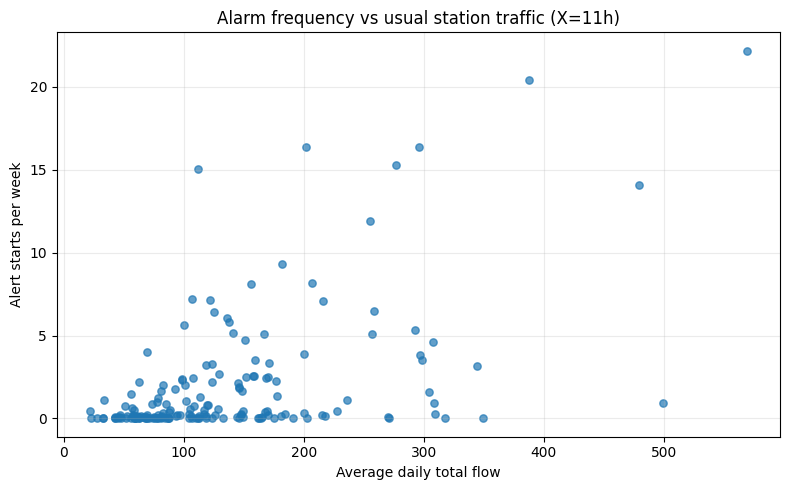

In [40]:
# Task 1: rank alarm-driving stations and join usual traffic profile
alarm_driver_df = con.execute("""
WITH alarm_events AS (
    SELECT
        canonical_station_id,
        event_ts,
        stockout_risk_flag,
        flag_start
    FROM station_stockout_events_x11
), date_span AS (
    SELECT
        date_diff('day', MIN(CAST(event_ts AS DATE)), MAX(CAST(event_ts AS DATE))) + 1 AS observed_days
    FROM alarm_events
), alarm_station AS (
    SELECT
        canonical_station_id,
        SUM(CASE WHEN stockout_risk_flag = 1 THEN 1 ELSE 0 END) AS flagged_events,
        SUM(CASE WHEN stockout_risk_flag = 1 THEN flag_start ELSE 0 END) AS alert_starts,
        COUNT(*) AS station_events_evaluated
    FROM alarm_events
    GROUP BY canonical_station_id
), flows AS (
    SELECT
        start_canonical_station_id AS canonical_station_id,
        CAST(start_time_ms AS DATE) AS event_day,
        0 AS inflow,
        1 AS outflow
    FROM rides_data_scoping
    WHERE start_canonical_station_id IS NOT NULL
    UNION ALL
    SELECT
        end_canonical_station_id AS canonical_station_id,
        CAST(end_time_ms AS DATE) AS event_day,
        1 AS inflow,
        0 AS outflow
    FROM rides_data_scoping
    WHERE end_canonical_station_id IS NOT NULL
), station_day_flow AS (
    SELECT
        canonical_station_id,
        event_day,
        SUM(inflow) AS daily_inflow,
        SUM(outflow) AS daily_outflow,
        SUM(inflow + outflow) AS daily_total_flow
    FROM flows
    GROUP BY canonical_station_id, event_day
), traffic AS (
    SELECT
        canonical_station_id,
        AVG(daily_inflow) AS avg_daily_inflow,
        AVG(daily_outflow) AS avg_daily_outflow,
        AVG(daily_total_flow) AS avg_daily_total_flow,
        quantile_cont(daily_total_flow, 0.5) AS p50_daily_total_flow,
        quantile_cont(daily_total_flow, 0.9) AS p90_daily_total_flow
    FROM station_day_flow
    GROUP BY canonical_station_id
)
SELECT
    a.canonical_station_id,
    a.alert_starts,
    a.flagged_events,
    ROUND(1000.0 * a.flagged_events / NULLIF(a.station_events_evaluated, 0), 3) AS flagged_events_per_1k_events,
    ROUND(1.0 * a.alert_starts / ds.observed_days, 4) AS alert_starts_per_day,
    ROUND(7.0 * a.alert_starts / ds.observed_days, 4) AS alert_starts_per_week,
    ROUND(t.avg_daily_inflow, 2) AS avg_daily_inflow,
    ROUND(t.avg_daily_outflow, 2) AS avg_daily_outflow,
    ROUND(t.avg_daily_total_flow, 2) AS avg_daily_total_flow,
    ROUND(t.p50_daily_total_flow, 2) AS p50_daily_total_flow,
    ROUND(t.p90_daily_total_flow, 2) AS p90_daily_total_flow
FROM alarm_station a
CROSS JOIN date_span ds
LEFT JOIN traffic t USING (canonical_station_id)
WHERE a.alert_starts > 0
ORDER BY a.alert_starts DESC, a.flagged_events DESC
""").df()

top_alarm_drivers_df = alarm_driver_df.head(25).copy()

print(f"Stations with at least one alert: {len(alarm_driver_df):,}")
print("Top stations sorted by alert starts (frequency driver):")
display(top_alarm_drivers_df)

traffic_profile_summary_df = alarm_driver_df[[
    'alert_starts_per_week', 'avg_daily_inflow', 'avg_daily_outflow', 'avg_daily_total_flow'
]].describe().T
display(traffic_profile_summary_df)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(
    alarm_driver_df['avg_daily_total_flow'],
    alarm_driver_df['alert_starts_per_week'],
    alpha=0.7,
    s=28,
 )
ax.set_title('Alarm frequency vs usual station traffic (X=11h)')
ax.set_xlabel('Average daily total flow')
ax.set_ylabel('Alert starts per week')
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [41]:
# Episode-based alarm drivers with false-alarm adjustment
if 'episode_df' not in globals():
    raise ValueError("Run the episode diagnostics cell first to create episode_df.")

observed_days = con.execute("""
SELECT date_diff('day', MIN(CAST(event_ts AS DATE)), MAX(CAST(event_ts AS DATE))) + 1 AS observed_days
FROM station_stockout_events_x11
""").df().iloc[0, 0]

episode_driver_df = episode_df.copy()
episode_driver_df['likely_true_alarm'] = 1 - episode_driver_df['likely_false_alarm']
episode_driver_df['severity_score'] = (
    episode_driver_df['peak_excess_over_capacity'].clip(lower=0)
    * np.log1p(episode_driver_df['episode_duration_min'].clip(lower=0))
 )

episode_station_driver_df = (
    episode_driver_df.groupby('canonical_station_id', as_index=False)
    .agg(
        total_episodes=('episode_id', 'count'),
        likely_false_alarm_episodes=('likely_false_alarm', 'sum'),
        likely_true_alarm_episodes=('likely_true_alarm', 'sum'),
        median_episode_duration_min=('episode_duration_min', 'median'),
        p90_episode_duration_min=('episode_duration_min', lambda s: s.quantile(0.90)),
        avg_peak_excess=('peak_excess_over_capacity', 'mean'),
        max_peak_excess=('peak_excess_over_capacity', 'max'),
        total_severity_score=('severity_score', 'sum')
    )
    .sort_values(['likely_true_alarm_episodes', 'total_severity_score'], ascending=[False, False])
    .reset_index(drop=True)
)

episode_station_driver_df['false_alarm_rate_pct'] = (
    100.0 * episode_station_driver_df['likely_false_alarm_episodes']
    / episode_station_driver_df['total_episodes'].replace(0, np.nan)
)
episode_station_driver_df['true_alarm_rate_pct'] = 100.0 - episode_station_driver_df['false_alarm_rate_pct']
episode_station_driver_df['likely_true_episodes_per_week'] = (
    7.0 * episode_station_driver_df['likely_true_alarm_episodes'] / observed_days
)
episode_station_driver_df['likely_false_episodes_per_week'] = (
    7.0 * episode_station_driver_df['likely_false_alarm_episodes'] / observed_days
)

# Join with usual traffic profile from prior station traffic analysis
if 'alarm_driver_df' in globals():
    traffic_cols = [
        'canonical_station_id', 'avg_daily_inflow', 'avg_daily_outflow', 'avg_daily_total_flow',
        'p50_daily_total_flow', 'p90_daily_total_flow'
    ]
    traffic_lookup_df = alarm_driver_df[traffic_cols].drop_duplicates('canonical_station_id')
    episode_station_driver_df = episode_station_driver_df.merge(
        traffic_lookup_df, on='canonical_station_id', how='left'
    )

top_true_alarm_drivers_df = episode_station_driver_df.sort_values(
    ['likely_true_alarm_episodes', 'total_severity_score'], ascending=[False, False]
).head(25).copy()

top_false_alarm_prone_df = episode_station_driver_df.sort_values(
    ['false_alarm_rate_pct', 'total_episodes'], ascending=[False, False]
).head(25).copy()

print(f"Observed days in scope: {observed_days}")
print("Top 25 stations driving likely TRUE alarms (episode-based):")
display(top_true_alarm_drivers_df[[
    'canonical_station_id',
    'likely_true_alarm_episodes',
    'likely_true_episodes_per_week',
    'false_alarm_rate_pct',
    'median_episode_duration_min',
    'avg_peak_excess',
    'max_peak_excess',
    'total_severity_score',
    'avg_daily_total_flow'
]])

print("\nTop 25 stations most false-alarm-prone (episode-based):")
display(top_false_alarm_prone_df[[
    'canonical_station_id',
    'total_episodes',
    'likely_false_alarm_episodes',
    'false_alarm_rate_pct',
    'likely_true_alarm_episodes',
    'median_episode_duration_min',
    'avg_peak_excess',
    'avg_daily_total_flow'
]])

Observed days in scope: 766
Top 25 stations driving likely TRUE alarms (episode-based):


,canonical_station_id,likely_true_alarm_episodes,likely_true_episodes_per_week,false_alarm_rate_pct,median_episode_duration_min,avg_peak_excess,max_peak_excess,total_severity_score,avg_daily_total_flow
0,STN_0001,1069,9.768930,55.935697,2.0,5.245672,107.0,51270.747158,569.40
1,STN_0002,935,8.544386,58.184258,2.0,4.113596,63.0,34733.451021,387.83
2,STN_0088,859,7.849869,51.984349,7.0,4.912800,69.0,40093.392220,202.06
3,STN_0034,817,7.466057,51.223881,6.0,5.864478,302.0,45973.699095,276.53
4,STN_0011,793,7.246736,55.747768,3.0,5.118304,71.0,41472.200770,296.12
5,STN_0166,734,6.707572,55.461165,5.0,3.439320,32.0,22636.859496,112.14
6,STN_0003,727,6.643603,52.730819,3.0,10.437581,151.0,88660.298661,479.62
7,STN_0017,722,6.597911,44.631902,11.0,14.157209,96.0,112811.208327,254.82
8,STN_0180,481,4.395561,39.036755,44.0,8.640051,59.0,38013.667064,107.06
9,STN_0025,439,4.011749,43.208279,9.0,9.774903,477.0,39105.493134,216.10



Top 25 stations most false-alarm-prone (episode-based):


,canonical_station_id,total_episodes,likely_false_alarm_episodes,false_alarm_rate_pct,likely_true_alarm_episodes,median_episode_duration_min,avg_peak_excess,avg_daily_total_flow
154,STN_0224,24,24,100.0,0,0.0,1.000000,96.81
143,STN_0473,9,9,100.0,0,0.0,1.222222,80.77
153,STN_0145,7,7,100.0,0,0.0,1.000000,165.23
162,STN_0584,7,7,100.0,0,0.0,1.000000,74.92
146,STN_1261,4,4,100.0,0,0.5,1.500000,45.41
151,STN_0314,4,4,100.0,0,0.0,1.250000,77.44
163,STN_0592,4,4,100.0,0,0.0,1.000000,164.53
173,STN_1082,4,4,100.0,0,0.0,1.000000,55.61
147,STN_0181,3,3,100.0,0,0.0,1.333333,106.65
159,STN_0399,3,3,100.0,0,0.0,1.000000,62.99


In [44]:
# Save episode_summary_df to silver/station_capacity_episode as CSV
output_dir = Path("data/silver/station_capacity_episode")
output_dir.mkdir(parents=True, exist_ok=True)

output_csv_path = output_dir / "episode_df.csv"
episode_df.to_csv(output_csv_path, index=False)

print(f"Saved: {output_csv_path}")
display(episode_df)

Saved: data/silver/station_capacity_episode/episode_df.csv


,canonical_station_id,episode_id,episode_start_ts,episode_end_ts,flagged_event_count,peak_excess_over_capacity,avg_excess_over_capacity,episode_duration_min,likely_false_alarm
0,STN_0003,1046.0,2025-07-27 18:42:11,2025-07-28 06:01:27,387,52.0,28.674419,679,0
1,STN_0003,1048.0,2025-07-28 20:07:37,2025-07-28 20:13:58,6,2.0,1.333333,6,1
2,STN_0003,1049.0,2025-07-28 20:16:05,2025-07-28 20:16:57,3,2.0,1.333333,0,1
3,STN_0003,1051.0,2025-07-28 20:59:32,2025-07-28 22:50:18,153,13.0,7.869281,111,0
4,STN_0003,1052.0,2025-07-28 22:57:02,2025-07-28 23:12:40,12,6.0,3.500000,15,0
...,...,...,...,...,...,...,...,...,...
37967,STN_0790,16.0,2025-10-22 05:45:48,2025-10-22 05:45:48,1,2.0,2.000000,0,1
37968,STN_0790,17.0,2025-10-28 04:36:23,2025-10-28 04:36:23,1,2.0,2.000000,0,1
37969,STN_0911,3.0,2025-06-08 00:07:01,2025-06-08 00:07:01,1,1.0,1.000000,0,1
37970,STN_0911,4.0,2025-07-08 19:32:31,2025-07-08 21:39:47,27,5.0,3.037037,127,0
